--- Fitting GARCH(1,1) Models ---
Processing JPM...
Processing GS...
Processing MS...
Processing BAC...
Processing C...
Processing DB...
Processing BCS...

--- Model Parameters (Alpha + Beta) ---
Alpha = Reaction to Shock, Beta = Persistence
           Omega     Alpha      Beta  Sum (Persistence)
Ticker                                                 
JPM     0.102324  0.106614  0.859212           0.965826
GS      0.154180  0.092599  0.862413           0.955012
MS      0.340252  0.121952  0.787779           0.909732
BAC     0.269606  0.151971  0.781443           0.933414
C       0.229441  0.152444  0.796839           0.949283
DB      0.229574  0.056881  0.908225           0.965107
BCS     0.243472  0.098590  0.860236           0.958826


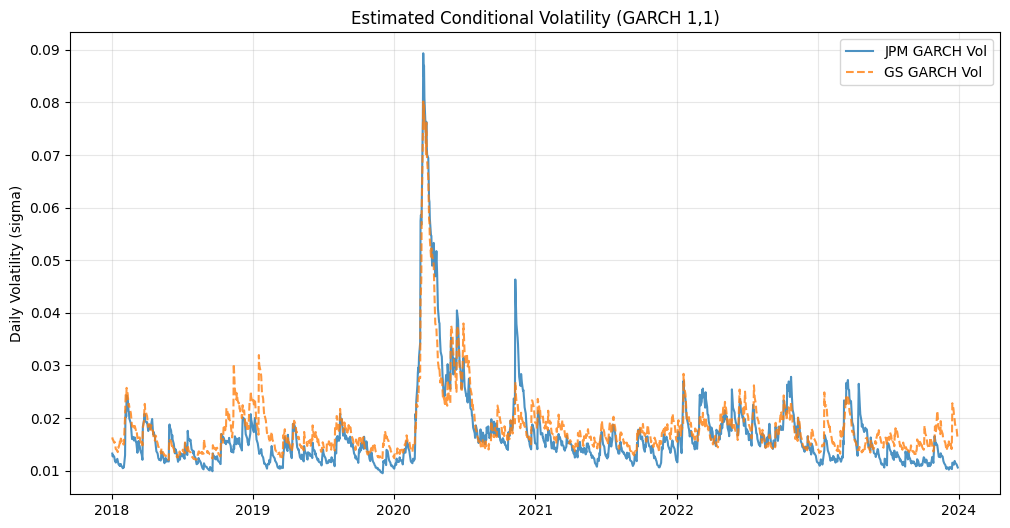


[SUCCESS] GARCH volatility saved to: ..\..\data\processed\garch_volatility.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
import os
import warnings
warnings.filterwarnings("ignore")

# 1. Load Processed Data
# Adjust path if necessary
try:
    path = os.path.join("..", "..", "data", "processed", "market_returns.csv")
    returns_df = pd.read_csv(path, index_col=0, parse_dates=True)
except FileNotFoundError:
    # Fallback to absolute path
    path = r"c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Risk Management & Sustainability (ESG)\Quantifying Systemic Risk in Central Clearing Counterparties (CCPs)\data\processed\market_returns.csv"
    returns_df = pd.read_csv(path, index_col=0, parse_dates=True)

# 2. Define the Modeling Function
def fit_garch(ticker, returns):
    """
    Fits a GARCH(1,1) model to the returns series.
    Returns the conditional volatility (sigma).
    """
    # Scale returns by 100 for better numerical stability in optimization
    scaled_returns = returns * 100
    
    # Define GARCH(1,1) model with Constant Mean and Normal Errors
    model = arch_model(scaled_returns, vol='Garch', p=1, q=1, mean='Constant', dist='Normal')
    
    # Fit the model
    res = model.fit(disp='off', show_warning=False)
    
    # Extract conditional volatility and rescale back
    cond_vol = res.conditional_volatility / 100
    return cond_vol, res

# 3. Fit Models for All Clearing Members (CMs)
cm_tickers = ['JPM', 'GS', 'MS', 'BAC', 'C', 'DB', 'BCS']
garch_volatility = pd.DataFrame(index=returns_df.index)
model_summaries = {}

print("--- Fitting GARCH(1,1) Models ---")
for ticker in cm_tickers:
    print(f"Processing {ticker}...")
    vol, res = fit_garch(ticker, returns_df[ticker])
    garch_volatility[ticker] = vol
    model_summaries[ticker] = res

# 4. Save the Volatility Parameters (Theta)
# We need these specifically for the simulation phase later
print("\n--- Model Parameters (Alpha + Beta) ---")
print("Alpha = Reaction to Shock, Beta = Persistence")
params_list = []
for ticker in cm_tickers:
    params = model_summaries[ticker].params
    params_list.append({
        'Ticker': ticker,
        'Omega': params['omega'],
        'Alpha': params['alpha[1]'],
        'Beta': params['beta[1]'],
        'Sum (Persistence)': params['alpha[1]'] + params['beta[1]']
    })

params_df = pd.DataFrame(params_list).set_index('Ticker')
print(params_df)

# 5. Visual Validation
plt.figure(figsize=(12, 6))
plt.plot(garch_volatility['JPM'], label='JPM GARCH Vol', alpha=0.8)
plt.plot(garch_volatility['GS'], label='GS GARCH Vol', alpha=0.8, linestyle='--')
plt.title("Estimated Conditional Volatility (GARCH 1,1)")
plt.ylabel("Daily Volatility (sigma)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Save GARCH Volatility Data
output_path = os.path.join("..", "..", "data", "processed", "garch_volatility.csv")
os.makedirs(os.path.dirname(output_path), exist_ok=True)
garch_volatility.to_csv(output_path)
print(f"\n[SUCCESS] GARCH volatility saved to: {output_path}")